In [26]:
using LinearAlgebra
using DifferentialEquations
using BoundaryValueDiffEq
using Plots
using PyCall
using DelimitedFiles

In [42]:
py"""
import numpy as np
from scipy.integrate import solve_bvp
import matplotlib.pyplot as plt
import math
from math import sqrt
Re_s = 975
def oneDiskODE(z,y):
        # Y0 = H, Y1 = F,Y2 = F', Y3 = F'', Y4 = G, Y5 = G'
        dH = -2 * sqrt(Re_s) * y[1]
        dydz = np.zeros((6, len(z)))
        dydz = np.array([dH , y[2] , y[3] , Re_s * ( (1/sqrt(Re_s)) * ( y[3] * y[0] + y[2] * dH) - 2 * y[4] * y[5] + 2 * y[1] * y[2]) , y[5] , Re_s * ( (1/sqrt(Re_s)) * y[5] * y[0] + 2 * y[1] * y[4])])
        return dydz 

def oneDiskBC(ya, yb):
        resa = np.array([ya[0],ya[1], ya[4] - 1.0])
        
        resb = np.array([yb[0],yb[1], yb[4]])
        
        return np.concatenate((resa, resb))


z = np.linspace(0, 1, 20000)
y = np.zeros((6, len(z)))
y_guess = np.zeros((6, z.size))
y_guess[0] = 1
y_guess[1] = 0
y_guess[2] = 0
y_guess[3] = 0
y_guess[4] = 1
y_guess[5] = 0
solution = solve_bvp(oneDiskODE, oneDiskBC, z, y_guess,max_nodes=5000000)

x_plot = np.linspace(0, 1, 20000)


y1_plot = solution.sol(x_plot)[0]
y2_plot = solution.sol(x_plot)[1]
y3_plot = solution.sol(x_plot)[4]
y4_plot = solution.sol(x_plot)[2]
y5_plot = solution.sol(x_plot)[5]
"""
Re_s = py"Re_s"
w0 = py"y1_plot"
u0 = py"y2_plot"
v0 = py"y3_plot"
du0 = py"y4_plot"
dv0 = py"y5_plot"
x = py"x_plot"

20000-element Vector{Float64}:
 0.0
 5.000250012500625e-5
 0.0001000050002500125
 0.00015000750037501875
 0.000200010000500025
 0.00025001250062503126
 0.0003000150007500375
 0.00035001750087504374
 0.00040002000100005
 0.00045002250112505623
 ⋮
 0.9995999799989999
 0.999649982499125
 0.99969998499925
 0.9997499874993749
 0.9997999899994999
 0.9998499924996249
 0.9998999949997499
 0.9999499974998749
 1.0

In [43]:
velocity = [x u0 v0 w0 du0 dv0]
writedlm("Re_s = $Re_s.dat", velocity)

In [22]:
nu = 1.51 * 10 ^ (-5)
OMEGA = 1200
delta = sqrt(nu/OMEGA)
s = 0.015
Res = (s/delta)^2


17880.79470198675

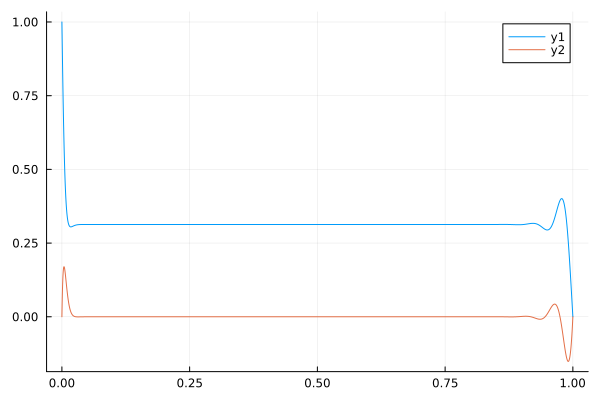

In [25]:
plot(x,v0)
plot!(x,u0)